**Load Data**

In [ ]:
!pip install biopython

from Bio import SeqIO

def clean_sequence(seq):
    seq = seq.upper()

    # Trim to 1000 bp if sequence is 1001 bp
    if len(seq) == 1001:
        seq = seq[:1000]

    # Reject anything not exactly 1000 bp after trimming
    if len(seq) != 1000:
        return None

    if "N" in seq:
        return None

    return seq

def load_promoters(path):
    seqs = []
    for record in SeqIO.parse(path, "fasta"):
        cleaned = clean_sequence(str(record.seq))
        if cleaned:
            seqs.append(cleaned)
    return seqs

promoters = load_promoters("human_promoters_500bp.fasta")
print("Loaded promoters:", len(promoters))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.8 MB/s eta 0:00:00
Loaded promoters: 29597


**Generate Negative Class**

In [ ]:
!wget -O hg38.fa.gz https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz
!gunzip hg38.fa.gz

# Load genome using pyfaidx
!pip install pyfaidx
from pyfaidx import Fasta

hg38 = Fasta("hg38.fa")


import random

def generate_negative_sequences(genome, n, length=1000):
    negs = []
    chroms = list(genome.keys())

    while len(negs) < n:
        chrom = random.choice(chroms)
        chrom_len = len(genome[chrom])

        if chrom_len <= length:
            continue

        start = random.randint(0, chrom_len - length)
        seq = str(genome[chrom][start:start+length]).upper()

        # Clean: must match promoter cleaning rules
        if "N" in seq:
            continue
        if len(seq) != length:
            continue

        negs.append(seq)

    return negs

non_promoters = generate_negative_sequences(hg38, len(promoters))
print("Generated negatives:", len(non_promoters))

--2026-04-30 23:35:39--  https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz
Resolving hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)... 128.114.119.163
Connecting to hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)|128.114.119.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 983659424 (938M) [application/x-gzip]
Saving to: ‘hg38.fa.gz’

hg38.fa.gz          100%[===================>] 938.09M  57.7MB/s    in 16s     

2026-04-30 23:35:56 (57.2 MB/s) - ‘hg38.fa.gz’ saved [983659424/983659424]

Generated negatives: 29597


**One-Hot Encode all sequences**

In [ ]:
import numpy as np

def one_hot_encode(seq):
    mapping = {'A':0, 'C':1, 'G':2, 'T':3}
    arr = np.zeros((1000, 4), dtype=np.float32)
    for i, base in enumerate(seq):
        if base in mapping:
            arr[i, mapping[base]] = 1.0
    return arr

# Combine promoters + negatives
all_sequences = promoters + non_promoters

# Encode
X = np.array([one_hot_encode(seq) for seq in all_sequences])

# Add channel dimension for 2D-CNN
X = X[..., np.newaxis]   # shape: (N, 1000, 4, 1)

# Labels
y = np.array([1]*len(promoters) + [0]*len(non_promoters))

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (59194, 1000, 4, 1)
y shape: (59194,)


**Train/validation/Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

# 80% train, 10% validation, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (47355, 1000, 4, 1)
Val: (5919, 1000, 4, 1)
Test: (5920, 1000, 4, 1)


**Build 2D-CNN Model**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model():
    model = models.Sequential([
        layers.Input(shape=(1000, 4, 1)),

        # First convolution block
        layers.Conv2D(
            filters=32,
            kernel_size=(5, 4),
            activation='relu',
        ),
        layers.MaxPooling2D(pool_size=(2, 1)),

        # Second convolution block
        layers.Conv2D(
            filters=64,
            kernel_size=(7, 1),
            activation='relu'
        ),
        layers.MaxPooling2D(pool_size=(2, 1)),

        # Flatten + dense layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),

        # Output layer
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    return model

model = build_model()
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 996, 1, 32)     │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 498, 1, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 492, 1, 64)     │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 246, 1, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 15744)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     2,015,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,030,561 (7.75 MB)

 Trainable params: 2,030,561 (7.75 MB)

 Non-trainable params: 0 (0.00 B)

**Train the 2D-CNN Model**

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,   # matches your presentation
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]
)

model.save("promoter_cnn2d.h5")
print("Model saved as promoter_cnn2d.h5")

Epoch 1/20
740/740 ━━━━━━━━━━━━━━━━━━━━ 87s 113ms/step - accuracy: 0.8231 - auc: 0.8972 - loss: 0.4016 - val_accuracy: 0.8476 - val_auc: 0.9268 - val_loss: 0.3444
Epoch 2/20
740/740 ━━━━━━━━━━━━━━━━━━━━ 81s 109ms/step - accuracy: 0.8586 - auc: 0.9328 - loss: 0.3281 - val_accuracy: 0.8686 - val_auc: 0.9435 - val_loss: 0.3098
Epoch 3/20
740/740 ━━━━━━━━━━━━━━━━━━━━ 80s 109ms/step - accuracy: 0.8784 - auc: 0.9485 - loss: 0.2892 - val_accuracy: 0.8750 - val_auc: 0.9515 - val_loss: 0.2949
Epoch 4/20
740/740 ━━━━━━━━━━━━━━━━━━━━ 81s 108ms/step - accuracy: 0.8933 - auc: 0.9576 - loss: 0.2626 - val_accuracy: 0.8907 - val_auc: 0.9561 - val_loss: 0.2687
Epoch 5/20
740/740 ━━━━━━━━━━━━━━━━━━━━ 88s 115ms/step - accuracy: 0.9039 - auc: 0.9650 - loss: 0.2387 - val_accuracy: 0.8922 - val_auc: 0.9590 - val_loss: 0.2591
Epoch 6/20
740/740 ━━━━━━━━━━━━━━━━━━━━ 82s 110ms/step - accuracy: 0.9112 - auc: 0.9690 - loss: 0.2246 - val_accuracy: 0.8883 - val_auc: 0.9608 - val_loss: 0.2634
Epoch 7/20
740/740 ━━━

Model saved as promoter_cnn2d.h5


**Evaluate Model (Accuracy, ROC-AUC, Confusion Matrix)**

In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# Predict probabilities
y_pred_prob = model.predict(X_test).ravel()

# Convert probabilities → binary predictions
y_pred = (y_pred_prob > 0.5).astype(int)

# Accuracy
acc = accuracy_score(y_test, y_pred)

# ROC curve + AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Test Accuracy:", acc)
print("Test AUC:", roc_auc)
print("Confusion Matrix:\n", cm)

185/185 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
Test Accuracy: 0.9067567567567567
Test AUC: 0.9682850164353543
Confusion Matrix:
 [[2682  278]
 [ 274 2686]]


**Plot ROC Curve**

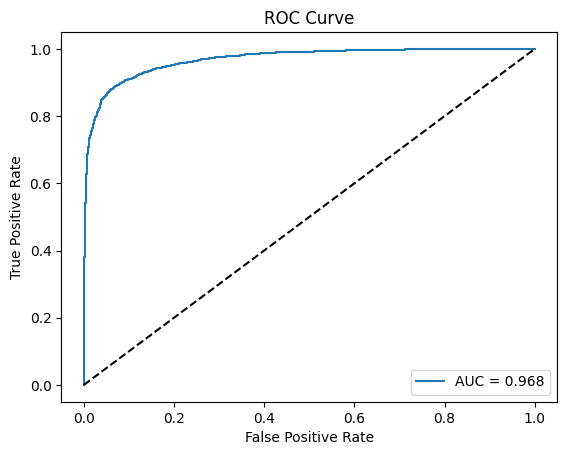

In [ ]:
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Plot Confusion Matrix**

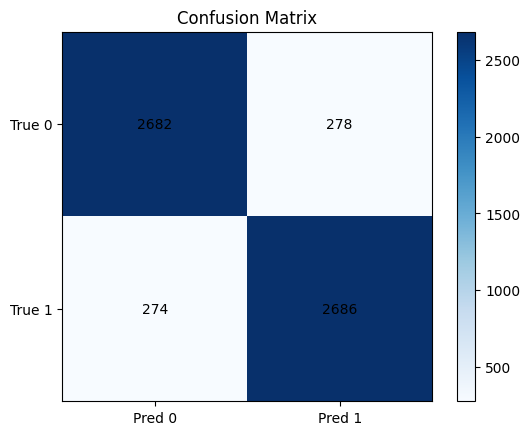

In [ ]:
plt.figure()
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["Pred 0", "Pred 1"])
plt.yticks([0,1], ["True 0", "True 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.show()